In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import holidays

# Check the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 1. data loading

csv_path = '/content/data.csv'
parquet_path = '/content/train-00000-of-00001.parquet'

# Load from CSV first.
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path, parse_dates=['timestamp'])
    print(f"Loading data from CSV, shape:{df.shape}")
    if 'id' not in df.columns:
        print("Warning: The 'id' column is missing in the CSV file.")
        df = None
    else:
        print("The CSV file contains an 'id' column, which can be used directly.")
else:
    df = None

if df is None:
    # Reload from parquet
    print("Loading original data...")
    df = pd.read_parquet(parquet_path)
    # Expand the list (each customer's row becomes multiple rows)
    df = df.explode(['timestamp', 'target']).reset_index(drop=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print(f"Expanded data shape: {df.shape}")
    print(f"列名: {df.columns.tolist()}")

    # Add time-related characteristics
    print("Add time-related characteristics...")
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek  # 0=Monday,6=Sunday
    df['month'] = df['timestamp'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Season: Winter (12, 1, 2) = 0, Spring = 1, Summer = 2, Autumn = 3
    def get_season(month):
        if month in [12, 1, 2]:
            return 0
        elif month in [3, 4, 5]:
            return 1
        elif month in [6, 7, 8]:
            return 2
        else:
            return 3
    df['season'] = df['month'].apply(get_season)

    # Holidays (using Portuguese holidays)
    pt_holidays = holidays.Portugal(years=range(2012, 2015))
    df['is_holiday'] = df['timestamp'].dt.date.apply(lambda x: 1 if x in pt_holidays else 0)

    # Handling of missing values (marking first, then filling)
    df['is_imputed'] = 0  # Initialize to 0. If any is missing, mark it.
    if df['target'].isnull().any():
        print("There are missing values. Forward filling is performed and an flag is added...")
        df['is_imputed'] = df.groupby('id')['target'].transform(lambda x: x.isnull().astype(int))
        df['target'] = df.groupby('id')['target'].fillna(method='ffill').fillna(method='bfill')

    # Save to CSV for future use (including ID)
    df.to_csv(csv_path, index=False)
    print(f"The data has been saved to{csv_path}")

print("Final data shape:", df.shape)
print("The scope of time:", df['timestamp'].min(), "->", df['timestamp'].max())
print("The number of clients", df['id'].nunique())
print("Statistical analysis of missing values:\n", df.isnull().sum())

Using device: cpu
Loading original data...
Expanded data shape: (8443584, 3)
列名: ['id', 'timestamp', 'target']
Add time-related characteristics...
The data has been saved to/content/data.csv
Final data shape: (8443584, 10)
The scope of time: 2012-01-01 01:00:00 -> 2015-01-01 00:00:00
The number of clients 321
Statistical analysis of missing values:
 id            0
timestamp     0
target        0
hour          0
dayofweek     0
month         0
is_weekend    0
season        0
is_holiday    0
is_imputed    0
dtype: int64


In [ ]:
# Select the top 20 customers for accelerated training
use_subset_clients = True
if use_subset_clients:
    # Obtain all unique customer IDs, sort them and then select the top 20
    all_ids_sorted = sorted(df['id'].unique())
    selected_clients = all_ids_sorted[:20]
    df = df[df['id'].isin(selected_clients)].reset_index(drop=True)
    print(f"The number of remaining customers after screening: {df['id'].nunique()}")
    print(f"Data shape: {df.shape}")

The number of remaining customers after screening: 20
Data shape: (526080, 10)


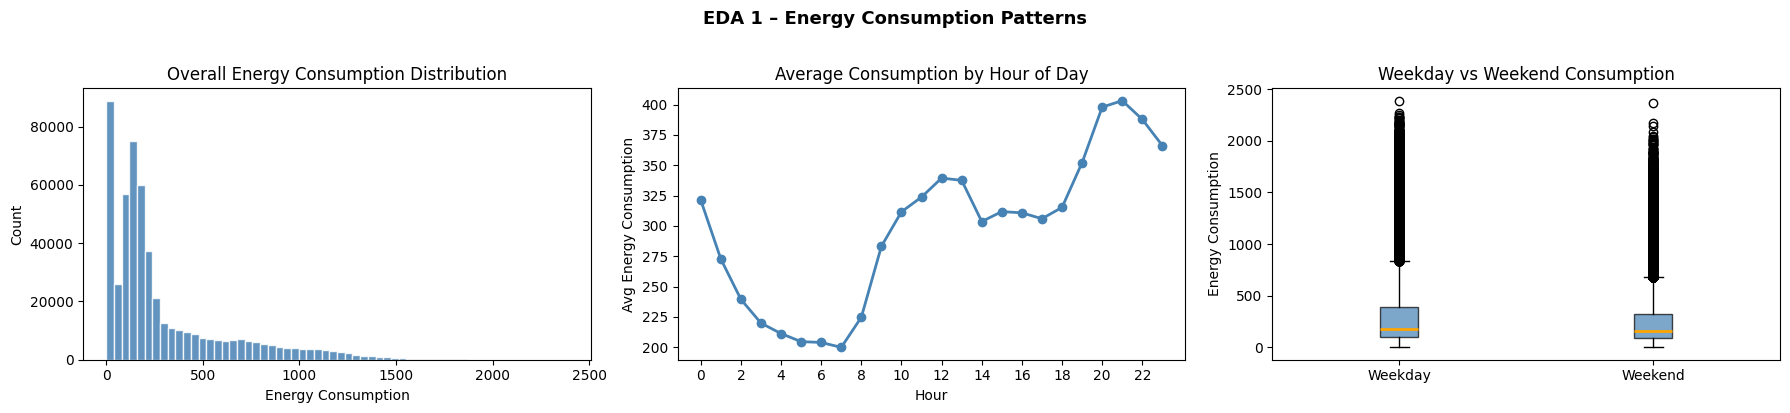

=== Basic Statistics ===
count     526080.0
unique      2006.0
top            8.0
freq       19021.0
Name: target, dtype: float64

Weekday mean: 305.665  |  Weekend mean: 278.319


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['target'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Overall Energy Consumption Distribution')
axes[0].set_xlabel('Energy Consumption')
axes[0].set_ylabel('Count')

hourly_avg = df.groupby('hour')['target'].mean()
axes[1].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Average Consumption by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Energy Consumption')
axes[1].set_xticks(range(0, 24, 2))

df['day_type'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
weekday_data = df[df['is_weekend'] == 0]['target'].dropna()
weekend_data = df[df['is_weekend'] == 1]['target'].dropna()
axes[2].boxplot([weekday_data, weekend_data], labels=['Weekday', 'Weekend'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='orange', linewidth=2))
axes[2].set_title('Weekday vs Weekend Consumption')
axes[2].set_ylabel('Energy Consumption')

plt.suptitle('EDA 1 – Energy Consumption Patterns', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=== Basic Statistics ===")
print(df['target'].describe().round(3))
print(f"\nWeekday mean: {weekday_data.mean():.3f}  |  Weekend mean: {weekend_data.mean():.3f}")


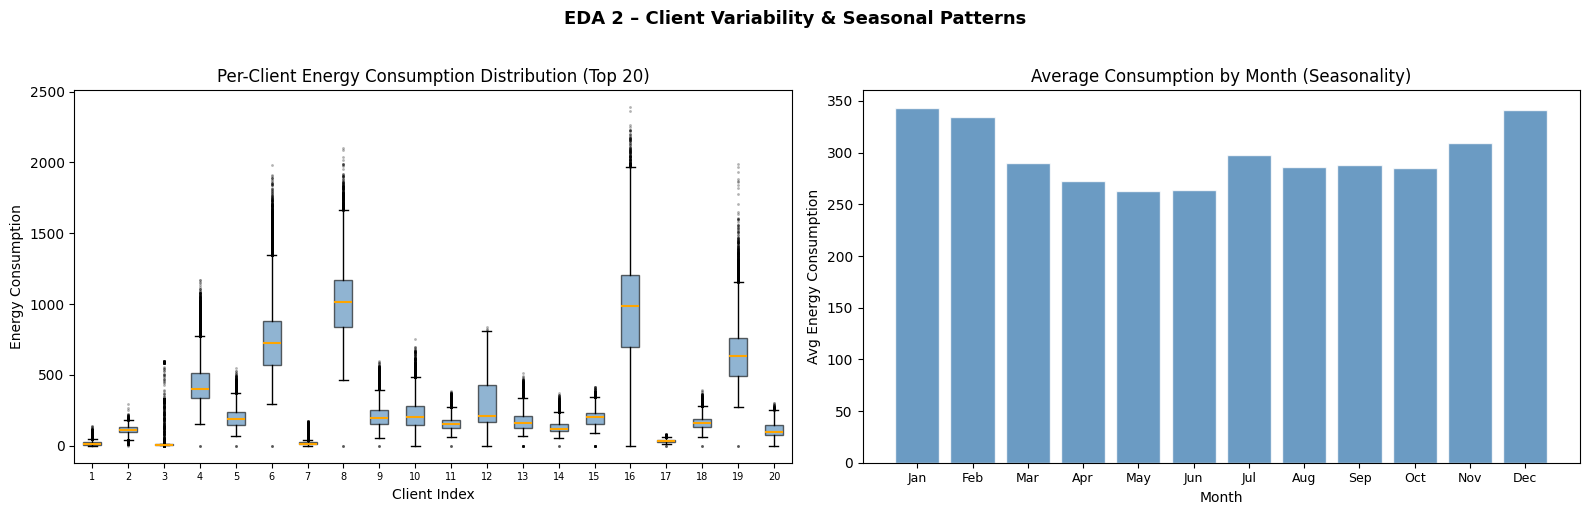

=== Client-level Statistics ===
               mean      std  min     max
id                                       
T000000   23.263762   24.127  0.0   140.0
T000001  112.885569   25.553  0.0   296.0
T000002   16.821624   49.190  0.0   601.0
T000003  440.335196  152.601  0.0  1170.0
T000004  200.536724   69.727  0.0   547.0
T000005  755.035166  249.599  0.0  1984.0
T000006   25.943659   27.392  0.0   178.0
T000007  1022.54927  231.480  0.0  2102.0
T000008  214.867321   83.793  0.0   600.0
T000009  227.069267  102.183  0.0   752.0
T000010  161.162637   48.707  0.0   385.0
T000011  295.797369  163.541  0.0   841.0
T000012  180.660318   71.644  0.0   511.0
T000013  134.116902   45.198  0.0   371.0
T000014  198.864127   52.454  0.0   417.0
T000015   983.10755  335.797  0.0  2389.0
T000016   35.822651    9.643  0.0    85.0
T000017  165.367777   44.473  0.0   394.0
T000018  651.264218  198.513  0.0  1989.0
T000019  111.655033   49.233  0.0   304.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

client_data = [df[df['id'] == cid]['target'].dropna().values
               for cid in selected_clients]
bp = axes[0].boxplot(client_data, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     medianprops=dict(color='orange', linewidth=1.5),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title('Per-Client Energy Consumption Distribution (Top 20)')
axes[0].set_xlabel('Client Index')
axes[0].set_ylabel('Energy Consumption')
axes[0].set_xticks(range(1, 21))
axes[0].set_xticklabels(range(1, 21), fontsize=7)

monthly_avg = df.groupby('month')['target'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly_avg.index, monthly_avg.values, color='steelblue',
            alpha=0.8, edgecolor='white')
axes[1].set_title('Average Consumption by Month (Seasonality)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Energy Consumption')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([month_names[m-1] for m in monthly_avg.index], fontsize=9)

plt.suptitle('EDA 2 – Client Variability & Seasonal Patterns', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=== Client-level Statistics ===")
client_stats = df.groupby('id')['target'].agg(['mean','std','min','max']).round(3)
print(client_stats)


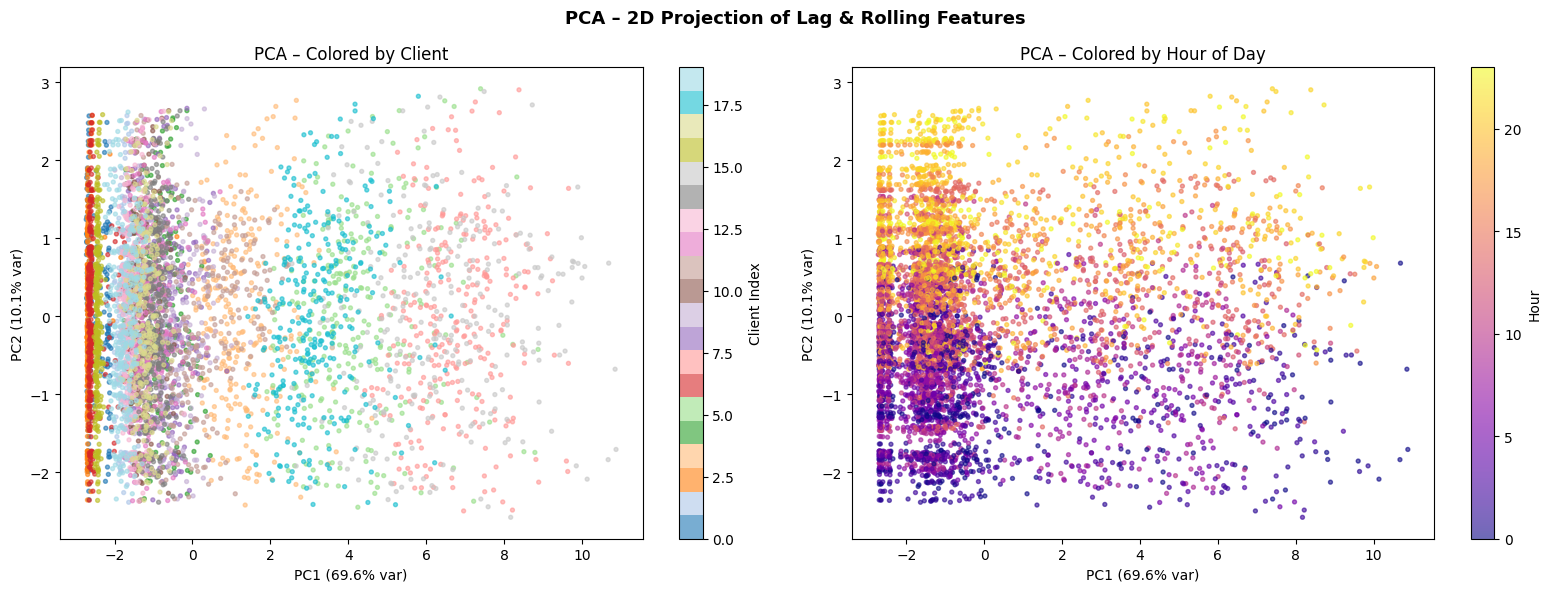

Total variance explained by PC1+PC2: 79.8%


In [ ]:
from sklearn.decomposition import PCA

PCA_FEATURES = (
    [f'lag_{l}h' for l in LAG_HOURS]
    + [f'roll_mean_{w}h' for w in ROLL_WINDOWS]
    + ['hour', 'dayofweek', 'month']
)

pca_sample = (df_rf.groupby('id', group_keys=False)
                   .apply(lambda g: g.sample(min(300, len(g)), random_state=42)))
pca_sample = pca_sample.dropna(subset=PCA_FEATURES)

X_pca = StandardScaler().fit_transform(pca_sample[PCA_FEATURES])
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

client_ids = pca_sample['id'].astype('category').cat.codes
sc1 = axes[0].scatter(components[:, 0], components[:, 1],
                      c=client_ids, cmap='tab20', s=8, alpha=0.6)
axes[0].set_title('PCA – Colored by Client')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(sc1, ax=axes[0], label='Client Index')

sc2 = axes[1].scatter(components[:, 0], components[:, 1],
                      c=pca_sample['hour'], cmap='plasma', s=8, alpha=0.6)
axes[1].set_title('PCA – Colored by Hour of Day')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(sc2, ax=axes[1], label='Hour')

plt.suptitle('PCA – 2D Projection of Lag & Rolling Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")


Running t-SNE on 2000 samples ...


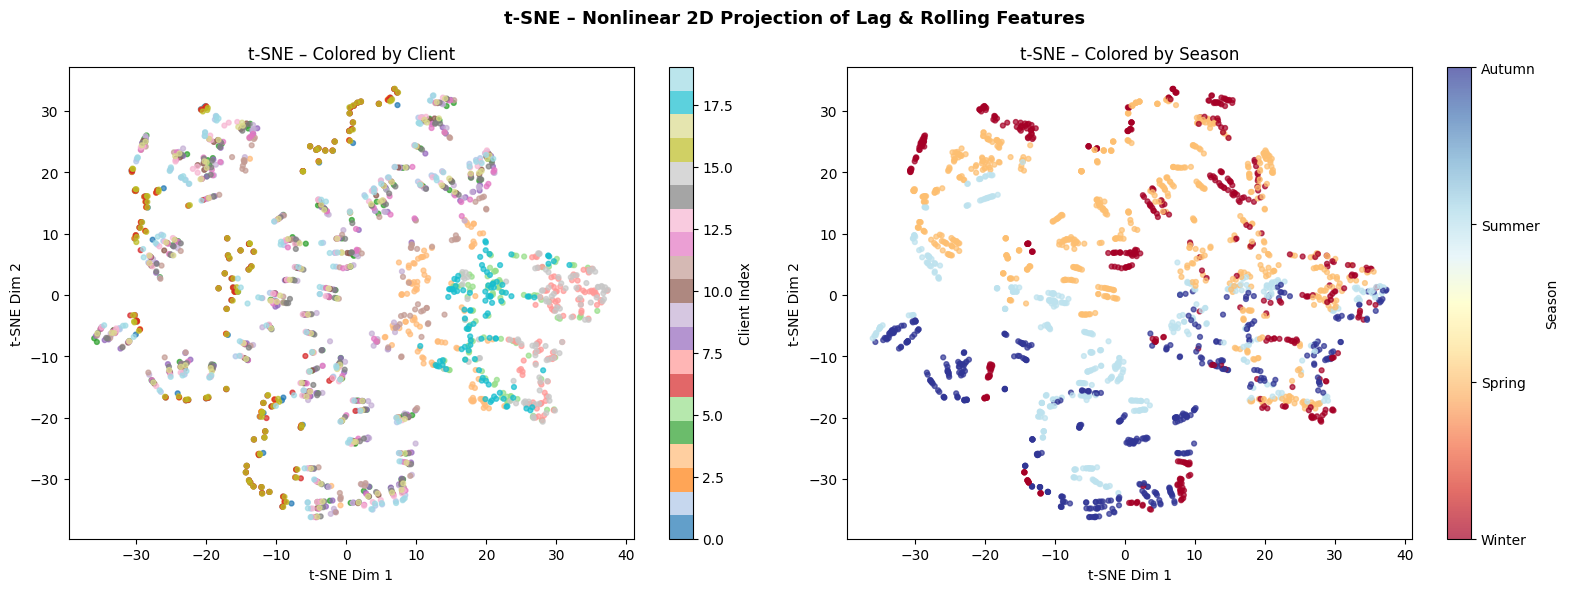

In [ ]:
from sklearn.manifold import TSNE

tsne_sample = (df_rf.groupby('id', group_keys=False)
                    .apply(lambda g: g.sample(min(100, len(g)), random_state=42)))
tsne_sample = tsne_sample.dropna(subset=PCA_FEATURES)

X_tsne = StandardScaler().fit_transform(tsne_sample[PCA_FEATURES])

print(f"Running t-SNE on {len(X_tsne)} samples ...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
emb  = tsne.fit_transform(X_tsne)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

client_ids_tsne = tsne_sample['id'].astype('category').cat.codes
sc1 = axes[0].scatter(emb[:, 0], emb[:, 1],
                      c=client_ids_tsne, cmap='tab20', s=12, alpha=0.7)
axes[0].set_title('t-SNE – Colored by Client')
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')
plt.colorbar(sc1, ax=axes[0], label='Client Index')

sc2 = axes[1].scatter(emb[:, 0], emb[:, 1],
                      c=tsne_sample['season'], cmap='RdYlBu', s=12, alpha=0.7)
axes[1].set_title('t-SNE – Colored by Season')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
cbar = plt.colorbar(sc2, ax=axes[1], label='Season')
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(['Winter', 'Spring', 'Summer', 'Autumn'])

plt.suptitle('t-SNE – Nonlinear 2D Projection of Lag & Rolling Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Random Forest Model
Baseline tree-based model using lag features + calendar features.  
Training is done on the first 20 clients (already filtered above).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# ── 1. Lag feature construction ──────────────────────────────────────────────
# Sort by client + time to ensure correct lag order
df_rf = df.sort_values(['id', 'timestamp']).copy()

LAG_HOURS   = [1, 2, 3, 6, 12, 24]          # short-term + daily lags
ROLL_WINDOWS = [6, 24, 48]                   # rolling statistics windows

print("Building lag & rolling features per client ...")
lag_parts = []
for cid, grp in df_rf.groupby('id'):
    grp = grp.copy()

    # Lag features
    for lag in LAG_HOURS:
        grp[f'lag_{lag}h'] = grp['target'].shift(lag)

    # Rolling mean & std (on the shifted series to avoid leakage)
    for w in ROLL_WINDOWS:
        grp[f'roll_mean_{w}h'] = grp['target'].shift(1).rolling(w).mean()
        grp[f'roll_std_{w}h']  = grp['target'].shift(1).rolling(w).std()

    lag_parts.append(grp)

df_rf = pd.concat(lag_parts).reset_index(drop=True)

# Drop rows with NaN introduced by lags (worst case = max lag)
df_rf.dropna(inplace=True)
print(f"Shape after lag feature construction: {df_rf.shape}")

Building lag & rolling features per client ...
Shape after lag feature construction: (525120, 22)


In [ ]:
# ── 2. Time-aware train / test split (80 / 20) ───────────────────────────────
# Use a single global cutoff to respect the temporal ordering
split_ts = df_rf['timestamp'].quantile(0.80)   # 80th-percentile timestamp
train_df = df_rf[df_rf['timestamp'] <= split_ts]
test_df  = df_rf[df_rf['timestamp'] >  split_ts]

FEATURE_COLS = (
    ['hour', 'dayofweek', 'month', 'is_weekend', 'season', 'is_holiday', 'is_imputed']
    + [f'lag_{l}h'         for l in LAG_HOURS]
    + [f'roll_mean_{w}h'   for w in ROLL_WINDOWS]
    + [f'roll_std_{w}h'    for w in ROLL_WINDOWS]
)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['target'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['target'].values

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Number of features: {X_train.shape[1]}")

Train size: 420,100  |  Test size: 105,020
Number of features: 19


In [ ]:
# ── 3. Train Random Forest ───────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=4,
    max_features='sqrt',
    n_jobs=-1,          # use all CPU cores
    random_state=42
)

print("Training Random Forest ...")
t0 = time.time()
rf_model.fit(X_train, y_train)
print(f"Training finished in {time.time() - t0:.1f}s")

Training Random Forest ...
Training finished in 337.1s


In [ ]:
# ── 3b. Hyperparameter Tuning with RandomizedSearchCV ────────────────────────
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [10, 15, 20, 30, None],
    'min_samples_leaf':[2, 4, 8, 16],
    'max_features':    ['sqrt', 'log2', 0.5],
    'min_samples_split':[2, 5, 10],
}

# Use TimeSeriesSplit to keep time ordering during CV
tscv_tune = TimeSeriesSplit(n_splits=3)

rf_base = RandomForestRegressor(n_jobs=-1, random_state=42)

search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,                  # try 20 random combinations
    scoring='neg_root_mean_squared_error',
    cv=tscv_tune,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running RandomizedSearchCV (20 combinations × 3-fold CV) ...")
t0 = time.time()
search.fit(X_train, y_train)
print(f"Search finished in {time.time() - t0:.1f}s")

print(f"\nBest CV RMSE : {-search.best_score_:.4f}")
print("Best params  :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

# Replace rf_model with the best estimator for subsequent evaluation
rf_model = search.best_estimator_
print("\nrf_model updated to best estimator.")


Running RandomizedSearchCV (20 combinations × 3-fold CV) ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Search finished in 16630.8s

Best CV RMSE : 74.2234
Best params  :
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 8
  max_features: 0.5
  max_depth: None

rf_model updated to best estimator.


In [ ]:
# ── 4. Evaluation ────────────────────────────────────────────────────────────
y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)

def report_metrics(y_true, y_pred, split_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    # MAPE – guard against zero targets
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"[{split_name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = report_metrics(y_train, y_pred_train, 'Train')
test_metrics  = report_metrics(y_test,  y_pred_test,  'Test ')

[Train]  MAE=14.6746  RMSE=28.0201  R²=0.9929  MAPE=6.79%
[Test ]  MAE=19.8857  RMSE=37.0415  R²=0.9870  MAPE=9.11%


In [ ]:
# ── 5. Time-Series Cross-Validation (5-fold) ─────────────────────────────────
# TimeSeriesSplit ensures each fold's test set is always in the future
tscv = TimeSeriesSplit(n_splits=5)

X_all = df_rf[FEATURE_COLS].values
y_all = df_rf['target'].values

# Use a lighter RF for CV to save time
rf_cv = RandomForestRegressor(
    n_estimators=100, max_depth=15,
    min_samples_leaf=4, max_features='sqrt',
    n_jobs=-1, random_state=42
)

print("Running 5-fold TimeSeriesSplit cross-validation ...")
cv_rmse_scores = []
cv_mae_scores  = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_all), 1):
    rf_cv.fit(X_all[tr_idx], y_all[tr_idx])
    preds = rf_cv.predict(X_all[val_idx])
    rmse  = np.sqrt(mean_squared_error(y_all[val_idx], preds))
    mae   = mean_absolute_error(y_all[val_idx], preds)
    cv_rmse_scores.append(rmse)
    cv_mae_scores.append(mae)
    print(f"  Fold {fold}: RMSE={rmse:.4f}  MAE={mae:.4f}")

print(f"\nCV RMSE: {np.mean(cv_rmse_scores):.4f} ± {np.std(cv_rmse_scores):.4f}")
print(f"CV MAE:  {np.mean(cv_mae_scores):.4f} ± {np.std(cv_mae_scores):.4f}")

Running 5-fold TimeSeriesSplit cross-validation ...
  Fold 1: RMSE=109.4619  MAE=56.0969
  Fold 2: RMSE=66.3305  MAE=42.2356
  Fold 3: RMSE=37.5433  MAE=21.6726
  Fold 4: RMSE=67.4934  MAE=33.2394
  Fold 5: RMSE=38.9822  MAE=23.8934

CV RMSE: 63.9623 ± 26.1161
CV MAE:  35.4276 ± 12.6538


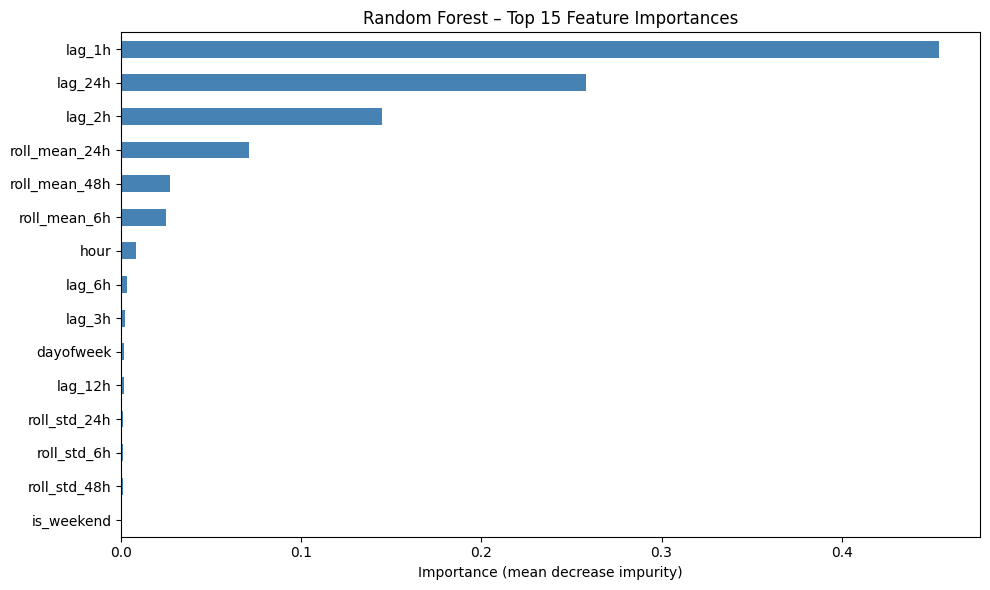


Top 10 features:
lag_1h           0.454113
lag_24h          0.257841
lag_2h           0.145046
roll_mean_24h    0.071114
roll_mean_48h    0.026908
roll_mean_6h     0.025129
hour             0.008139
lag_6h           0.003041
lag_3h           0.002229
dayofweek        0.001433


In [ ]:
# ── 6. Feature Importance ────────────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_sorted.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Random Forest – Top 15 Feature Importances')
plt.xlabel('Importance (mean decrease impurity)')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances_sorted.head(10).to_string())

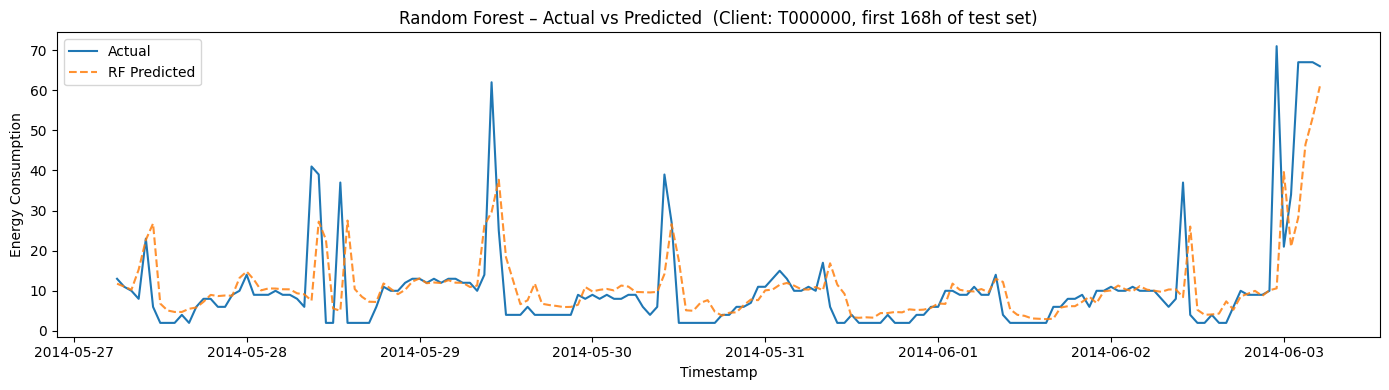


=== Random Forest Summary ===
  Train  MAE=14.6746  RMSE=28.0201  R²=0.9929
  Test   MAE=19.8857  RMSE=37.0415  R²=0.9870
  CV     RMSE=63.9623 ± 26.1161


In [ ]:
# ── 7. Prediction vs Actual Plot (one client, test period) ───────────────────
sample_client = selected_clients[0]
mask_client   = test_df['id'] == sample_client

ts_actual = test_df.loc[mask_client, 'timestamp'].values
y_actual  = y_test[mask_client.values]
y_rf_pred = y_pred_test[mask_client.values]

# Plot first 7 days (168 hours) for readability
n_plot = min(168, len(ts_actual))

plt.figure(figsize=(14, 4))
plt.plot(ts_actual[:n_plot], y_actual[:n_plot],  label='Actual',          linewidth=1.5)
plt.plot(ts_actual[:n_plot], y_rf_pred[:n_plot], label='RF Predicted',
         linestyle='--', linewidth=1.5, alpha=0.85)
plt.title(f'Random Forest – Actual vs Predicted  (Client: {sample_client}, first {n_plot}h of test set)')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption')
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Random Forest Summary ===")
print(f"  Train  MAE={train_metrics['MAE']:.4f}  RMSE={train_metrics['RMSE']:.4f}  R²={train_metrics['R2']:.4f}")
print(f"  Test   MAE={test_metrics['MAE']:.4f}  RMSE={test_metrics['RMSE']:.4f}  R²={test_metrics['R2']:.4f}")
print(f"  CV     RMSE={np.mean(cv_rmse_scores):.4f} ± {np.std(cv_rmse_scores):.4f}")